# 07 — Pricing and Auction Strategy Simulation

## Plate Value Intelligence

This notebook converts valuation and collectibility outputs into an explainable pricing and auction-routing simulation.

### Objectives

- Combine final holdout valuation predictions with asset-segmentation decisions
- Define transparent commercial routing rules
- Recommend fixed-price, standard-auction, premium-auction, or specialist-review pathways
- Create indicative reserve-price and pricing ranges
- Compare simulated decisions with observed B278 auction outcomes
- Quantify potential commercial opportunities and operational review volumes

### Scope and limitation

This is a decision-support simulation, not a causal pricing-optimisation engine.

The available public dataset does not include bidder histories, bid sequences, listing duration, customer-level demand, price elasticity, or alternative reserve-price experiments. Therefore, the analysis does not claim to identify the revenue-maximising price or auction format.

All strategy rules are transparent, scenario-based, and designed for later calibration with richer internal data.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [2]:
PROJECT_ROOT = Path.cwd()
REPORTS_DIR = PROJECT_ROOT / "reports"

VALUATION_PREDICTIONS_FILE = (
    REPORTS_DIR
    / "final_valuation_test_predictions_2025.csv"
)

ASSET_DECISIONS_FILE = (
    REPORTS_DIR
    / "premium_collectible_asset_decisions_2025.csv"
)

print(
    f"Valuation predictions exist: "
    f"{VALUATION_PREDICTIONS_FILE.exists()}"
)

print(
    f"Asset decisions exist: "
    f"{ASSET_DECISIONS_FILE.exists()}"
)

Valuation predictions exist: True
Asset decisions exist: True


In [3]:
df_valuation = pd.read_csv(
    VALUATION_PREDICTIONS_FILE
)

df_assets = pd.read_csv(
    ASSET_DECISIONS_FILE
)

print(
    f"Final valuation rows: "
    f"{len(df_valuation):,}"
)

print(
    f"Asset decision rows: "
    f"{len(df_assets):,}"
)

Final valuation rows: 1,981
Asset decision rows: 17,782


## 1. Input Validation

Final holdout valuation predictions are joined to the asset-decision layer using the auction event and lot number as the business key.

In [4]:
required_valuation_columns = [
    "event_code",
    "lot_number",
    "plate_raw",
    "hammer_price_gbp",
    "predicted_price_gbp",
    "residual_gbp",
    "absolute_error_gbp",
]

required_asset_columns = [
    "event_code",
    "lot_number",
    "plate_raw",
    "collectibility_score",
    "collectibility_segment",
    "premium_collectibility_group",
    "specialist_review_required",
    "specialist_review_reason",
    "model_split",
]

missing_valuation_columns = [
    column
    for column in required_valuation_columns
    if column not in df_valuation.columns
]

missing_asset_columns = [
    column
    for column in required_asset_columns
    if column not in df_assets.columns
]

assert not missing_valuation_columns, (
    f"Missing valuation columns: "
    f"{missing_valuation_columns}"
)

assert not missing_asset_columns, (
    f"Missing asset columns: "
    f"{missing_asset_columns}"
)

print("Required pricing-strategy inputs are available.")

Required pricing-strategy inputs are available.


In [5]:
df_assets_test = (
    df_assets.loc[
        df_assets["model_split"].eq("test")
    ]
    .copy()
)

print(
    f"B278 asset rows: "
    f"{len(df_assets_test):,}"
)

B278 asset rows: 1,981


In [6]:
assert len(df_assets_test) == len(df_valuation), (
    "B278 valuation and asset-decision row counts differ."
)

assert df_assets_test["event_code"].eq("B278").all()
assert df_valuation["event_code"].eq("B278").all()

print("Both datasets represent the untouched B278 event.")

Both datasets represent the untouched B278 event.


In [7]:
strategy_data = df_valuation.merge(
    df_assets_test[
        [
            "event_code",
            "lot_number",
            "collectibility_score",
            "collectibility_segment",
            "premium_collectibility_group",
            "specialist_review_required",
            "specialist_review_reason",
        ]
    ],
    on=[
        "event_code",
        "lot_number",
    ],
    how="left",
    validate="one_to_one",
)

In [8]:
print(
    f"Strategy rows: "
    f"{len(strategy_data):,}"
)

print(
    "Missing collectibility decisions: "
    f"{strategy_data['collectibility_score'].isna().sum():,}"
)

Strategy rows: 1,981
Missing collectibility decisions: 0


In [9]:
strategy_data[
    [
        "event_code",
        "lot_number",
        "plate_raw",
        "hammer_price_gbp",
        "predicted_price_gbp",
        "collectibility_score",
        "collectibility_segment",
        "premium_collectibility_group",
        "specialist_review_required",
    ]
].head(10)

,event_code,lot_number,plate_raw,hammer_price_gbp,predicted_price_gbp,collectibility_score,collectibility_segment,premium_collectibility_group,specialist_review_required
0,B278,1,855 A,"10,110.00","10,191.69",40,Collectible,Premium Value Only,1
1,B278,2,9811 A,"4,310.00","5,210.55",13,Standard,Standard Portfolio,0
2,B278,3,3000 AA,"5,010.00","3,562.25",18,Distinctive,Standard Portfolio,0
3,B278,4,A122 AAA,"4,790.00",886.34,18,Distinctive,Standard Portfolio,0
4,B278,5,A154 AAC,"1,510.00",907.53,7,Standard,Standard Portfolio,0
5,B278,6,AAB 10S,"1,010.00","1,913.34",27,Distinctive,Standard Portfolio,0
6,B278,7,AAD 96L,"2,510.00","1,090.30",17,Distinctive,Standard Portfolio,0
7,B278,8,AA54 EED,"1,010.00","1,246.40",17,Distinctive,Standard Portfolio,0
8,B278,9,A400 AGE,350.00,604.00,15,Distinctive,Standard Portfolio,0
9,B278,10,AAM 411D,"1,000.00","1,143.84",10,Standard,Standard Portfolio,0


## 2. Indicative Valuation Range

Point predictions are converted into an indicative valuation range. This range is a transparent scenario band rather than a formal statistical prediction interval.

In [10]:
strategy_data["valuation_low_gbp"] = (
    strategy_data["predicted_price_gbp"]
    * 0.80
)

strategy_data["valuation_central_gbp"] = (
    strategy_data["predicted_price_gbp"]
)

strategy_data["valuation_high_gbp"] = (
    strategy_data["predicted_price_gbp"]
    * 1.25
)

In [11]:
for column in [
    "valuation_low_gbp",
    "valuation_central_gbp",
    "valuation_high_gbp",
]:
    strategy_data[column] = (
        strategy_data[column]
        .round(-1)
    )

In [12]:
strategy_data["predicted_value_tier"] = pd.cut(
    strategy_data["predicted_price_gbp"],
    bins=[
        -np.inf,
        1_000,
        2_500,
        5_000,
        10_000,
        np.inf,
    ],
    labels=[
        "Entry",
        "Core",
        "Upper Core",
        "Premium",
        "Trophy Value",
    ],
)

In [13]:
predicted_value_tier_summary = (
    strategy_data.groupby(
        "predicted_value_tier",
        observed=True,
    )
    .agg(
        plate_count=("plate_raw", "size"),
        median_predicted_price=(
            "predicted_price_gbp",
            "median",
        ),
        median_observed_price=(
            "hammer_price_gbp",
            "median",
        ),
        median_collectibility_score=(
            "collectibility_score",
            "median",
        ),
    )
    .reset_index()
)

predicted_value_tier_summary

,predicted_value_tier,plate_count,median_predicted_price,median_observed_price,median_collectibility_score
0,Entry,662,709.75,640.00,15.00
1,Core,877,"1,434.86","1,500.00",23.00
2,Upper Core,281,"3,104.76","3,520.00",25.00
3,Premium,145,"5,604.39","6,300.00",57.00
4,Trophy Value,16,"10,675.36","10,070.00",38.50


## 3. Commercial Routing Policy

Each registration is assigned to an indicative sales pathway using predicted value, structural collectibility, and specialist-review requirements.

The policy is deliberately transparent and can later be calibrated using internal conversion, bidder, reserve-price, and revenue data.

In [14]:
strategy_data["recommended_sales_path"] = np.select(
    [
        strategy_data[
            "specialist_review_required"
        ].eq(1),

        (
            strategy_data[
                "collectibility_segment"
            ].isin(
                [
                    "High Collectible",
                    "Trophy Candidate",
                ]
            )
            & strategy_data[
                "predicted_price_gbp"
            ].ge(5_000)
        ),

        (
            strategy_data[
                "predicted_price_gbp"
            ].ge(2_500)
        ),
    ],
    [
        "Specialist Review",
        "Premium Auction / Showcase",
        "Standard Auction",
    ],
    default="Fixed Price",
)

In [15]:
def assign_sales_path_reason(row) -> str:
    if row["recommended_sales_path"] == "Specialist Review":
        return row["specialist_review_reason"]

    if (
        row["recommended_sales_path"]
        == "Premium Auction / Showcase"
    ):
        return (
            "high_collectibility_and_high_predicted_value"
        )

    if (
        row["recommended_sales_path"]
        == "Standard Auction"
    ):
        return (
            "meaningful_upside_and_competitive_bidding_potential"
        )

    return (
        "standard_asset_with_limited_auction_upside"
    )


strategy_data["sales_path_reason"] = (
    strategy_data.apply(
        assign_sales_path_reason,
        axis=1,
    )
)

In [16]:
sales_path_summary = (
    strategy_data.groupby(
        "recommended_sales_path"
    )
    .agg(
        plate_count=("plate_raw", "size"),
        median_predicted_price_gbp=(
            "predicted_price_gbp",
            "median",
        ),
        median_observed_price_gbp=(
            "hammer_price_gbp",
            "median",
        ),
        median_collectibility_score=(
            "collectibility_score",
            "median",
        ),
        specialist_review_count=(
            "specialist_review_required",
            "sum",
        ),
    )
    .reset_index()
    .sort_values(
        "median_predicted_price_gbp",
        ascending=False,
    )
)

sales_path_summary["portfolio_share_pct"] = (
    sales_path_summary["plate_count"]
    / len(strategy_data)
    * 100
)

sales_path_summary

,recommended_sales_path,plate_count,median_predicted_price_gbp,median_observed_price_gbp,median_collectibility_score,specialist_review_count,portfolio_share_pct
1,Premium Auction / Showcase,54,"7,240.53","7,005.00",47.00,0,2.73
2,Specialist Review,210,"4,623.96","6,730.00",37.00,210,10.60
3,Standard Auction,235,"3,104.76","3,260.00",25.00,0,11.86
0,Fixed Price,1482,"1,091.21","1,010.00",15.00,0,74.81


## 4. Pricing and Reserve-Price Policy

Indicative prices and reserve levels are assigned using transparent scenario rules.

These rules are not claimed to be revenue-optimal. They are business-policy assumptions designed for retrospective simulation and later calibration with internal bidder, conversion, elasticity, and reserve-price data.

In [17]:
pricing_policy = pd.DataFrame(
    {
        "recommended_sales_path": [
            "Fixed Price",
            "Standard Auction",
            "Premium Auction / Showcase",
            "Specialist Review",
        ],
        "reserve_ratio": [
            np.nan,
            0.70,
            0.65,
            np.nan,
        ],
        "listing_price_ratio": [
            1.10,
            np.nan,
            np.nan,
            np.nan,
        ],
        "policy_note": [
            "Transparent scenario assumption for retrospective simulation: list slightly above central valuation to allow pricing headroom.",
            "Transparent scenario assumption for retrospective simulation: use a moderate reserve to protect downside while supporting competition.",
            "Transparent scenario assumption for retrospective simulation: use a lower relative reserve to encourage bidding depth and price discovery.",
            "Transparent governance rule: no automatic price recommendation before specialist review.",
        ],
    }
)

pricing_policy


,recommended_sales_path,reserve_ratio,listing_price_ratio,policy_note
0,Fixed Price,NaN,1.10,List slightly above central valuation to allow pricing headroom.
1,Standard Auction,0.70,NaN,Use a moderate reserve to protect downside while supporting competition.
2,Premium Auction / Showcase,0.65,NaN,Use a lower relative reserve to encourage bidding depth and price discovery.
3,Specialist Review,NaN,NaN,No automatic price recommendation before specialist review.


In [18]:
strategy_data = strategy_data.merge(
    pricing_policy[
        [
            "recommended_sales_path",
            "reserve_ratio",
            "listing_price_ratio",
        ]
    ],
    on="recommended_sales_path",
    how="left",
    validate="many_to_one",
)

In [19]:
strategy_data["recommended_fixed_price_gbp"] = np.where(
    strategy_data["recommended_sales_path"].eq("Fixed Price"),
    (
        strategy_data["valuation_central_gbp"]
        * strategy_data["listing_price_ratio"]
    ),
    np.nan,
)


In [20]:
strategy_data["recommended_reserve_price_gbp"] = np.where(
    strategy_data[
        "recommended_sales_path"
    ].isin(
        [
            "Standard Auction",
            "Premium Auction / Showcase",
        ]
    ),
    (
        strategy_data["valuation_central_gbp"]
        * strategy_data["reserve_ratio"]
    ),
    np.nan,
)

In [21]:
for column in [
    "recommended_fixed_price_gbp",
    "recommended_reserve_price_gbp",
]:
    strategy_data[column] = (
        strategy_data[column]
        .round(-1)
    )

In [22]:
strategy_data[
    [
        "plate_raw",
        "recommended_sales_path",
        "valuation_low_gbp",
        "valuation_central_gbp",
        "valuation_high_gbp",
        "recommended_fixed_price_gbp",
        "recommended_reserve_price_gbp",
    ]
].head(20)

,plate_raw,recommended_sales_path,valuation_low_gbp,valuation_central_gbp,valuation_high_gbp,recommended_fixed_price_gbp,recommended_reserve_price_gbp
0,855 A,Specialist Review,"8,150.00","10,190.00","12,740.00",NaN,NaN
1,9811 A,Standard Auction,"4,170.00","5,210.00","6,510.00",NaN,"3,650.00"
2,3000 AA,Standard Auction,"2,850.00","3,560.00","4,450.00",NaN,"2,490.00"
3,A122 AAA,Fixed Price,710.00,890.00,"1,110.00",980.00,NaN
4,A154 AAC,Fixed Price,730.00,910.00,"1,130.00","1,000.00",NaN
5,AAB 10S,Fixed Price,"1,530.00","1,910.00","2,390.00","2,100.00",NaN
6,AAD 96L,Fixed Price,870.00,"1,090.00","1,360.00","1,200.00",NaN
7,AA54 EED,Fixed Price,"1,000.00","1,250.00","1,560.00","1,380.00",NaN
8,A400 AGE,Fixed Price,480.00,600.00,760.00,660.00,NaN
9,AAM 411D,Fixed Price,920.00,"1,140.00","1,430.00","1,250.00",NaN


In [23]:
specialist_mask = (
    strategy_data[
        "recommended_sales_path"
    ].eq("Specialist Review")
)

strategy_data.loc[
    specialist_mask,
    [
        "recommended_fixed_price_gbp",
        "recommended_reserve_price_gbp",
    ],
] = np.nan

In [24]:
assert strategy_data.loc[
    specialist_mask,
    "recommended_fixed_price_gbp",
].isna().all()

assert strategy_data.loc[
    specialist_mask,
    "recommended_reserve_price_gbp",
].isna().all()

print(
    "Specialist-review assets have no automatic "
    "listing or reserve price."
)

Specialist-review assets have no automatic listing or reserve price.


## 5. Retrospective Reserve Coverage

Observed hammer prices are compared with the simulated reserve recommendations.

This analysis does not show what would have happened under a different reserve. It only checks whether the indicative reserve would have been below the observed hammer price.

In [25]:
auction_mask = (
    strategy_data[
        "recommended_sales_path"
    ].isin(
        [
            "Standard Auction",
            "Premium Auction / Showcase",
        ]
    )
)

strategy_data["observed_price_above_reserve"] = np.where(
    auction_mask,
    (
        strategy_data["hammer_price_gbp"]
        >= strategy_data[
            "recommended_reserve_price_gbp"
        ]
    ).astype(int),
    np.nan,
)

In [26]:
reserve_coverage_summary = (
    strategy_data.loc[auction_mask]
    .groupby("recommended_sales_path")
    .agg(
        plate_count=("plate_raw", "size"),
        median_observed_price_gbp=(
            "hammer_price_gbp",
            "median",
        ),
        median_reserve_price_gbp=(
            "recommended_reserve_price_gbp",
            "median",
        ),
        observed_price_above_reserve_rate=(
            "observed_price_above_reserve",
            "mean",
        ),
    )
    .reset_index()
)

reserve_coverage_summary[
    "observed_price_above_reserve_rate_pct"
] = (
    reserve_coverage_summary[
        "observed_price_above_reserve_rate"
    ]
    * 100
)

reserve_coverage_summary

,recommended_sales_path,plate_count,median_observed_price_gbp,median_reserve_price_gbp,observed_price_above_reserve_rate,observed_price_above_reserve_rate_pct
0,Premium Auction / Showcase,54,"7,005.00","4,710.00",1.00,100.00
1,Standard Auction,235,"3,260.00","2,170.00",0.76,75.74


In [27]:
fixed_price_mask = (
    strategy_data[
        "recommended_sales_path"
    ].eq("Fixed Price")
)

strategy_data["observed_vs_recommended_fixed_gap_gbp"] = np.where(
    fixed_price_mask,
    (
        strategy_data["hammer_price_gbp"]
        - strategy_data[
            "recommended_fixed_price_gbp"
        ]
    ),
    np.nan,
)

In [28]:
fixed_price_summary = pd.DataFrame(
    {
        "plate_count": [
            int(fixed_price_mask.sum())
        ],
        "median_observed_price_gbp": [
            strategy_data.loc[
                fixed_price_mask,
                "hammer_price_gbp",
            ].median()
        ],
        "median_recommended_fixed_price_gbp": [
            strategy_data.loc[
                fixed_price_mask,
                "recommended_fixed_price_gbp",
            ].median()
        ],
        "median_observed_minus_recommended_gbp": [
            strategy_data.loc[
                fixed_price_mask,
                "observed_vs_recommended_fixed_gap_gbp",
            ].median()
        ],
    }
)

fixed_price_summary

,plate_count,median_observed_price_gbp,median_recommended_fixed_price_gbp,median_observed_minus_recommended_gbp
0,1482,"1,010.00","1,200.00",-190.00


In [29]:
strategy_calibration_summary = (
    strategy_data.groupby(
        "recommended_sales_path"
    )
    .agg(
        plate_count=("plate_raw", "size"),
        observed_total_value_gbp=(
            "hammer_price_gbp",
            "sum",
        ),
        median_observed_price_gbp=(
            "hammer_price_gbp",
            "median",
        ),
        median_predicted_price_gbp=(
            "predicted_price_gbp",
            "median",
        ),
        median_absolute_error_gbp=(
            "absolute_error_gbp",
            "median",
        ),
        median_collectibility_score=(
            "collectibility_score",
            "median",
        ),
    )
    .reset_index()
)

strategy_calibration_summary[
    "portfolio_share_pct"
] = (
    strategy_calibration_summary[
        "plate_count"
    ]
    / len(strategy_data)
    * 100
)

strategy_calibration_summary.sort_values(
    "median_observed_price_gbp",
    ascending=False,
)

,recommended_sales_path,plate_count,observed_total_value_gbp,median_observed_price_gbp,median_predicted_price_gbp,median_absolute_error_gbp,median_collectibility_score,portfolio_share_pct
1,Premium Auction / Showcase,54,"454,280.00","7,005.00","7,240.53","1,096.54",47.00,2.73
2,Specialist Review,210,"1,751,180.00","6,730.00","4,623.96","3,292.68",37.00,10.60
3,Standard Auction,235,"813,710.00","3,260.00","3,104.76",946.95,25.00,11.86
0,Fixed Price,1482,"2,076,650.00","1,010.00","1,091.21",495.26,15.00,74.81


## 6. Commercial Opportunity Flags

Differences between predicted and observed values are used as retrospective investigation signals, not as causal estimates of missed revenue.

In [30]:
strategy_data["valuation_gap_gbp"] = (
    strategy_data["predicted_price_gbp"]
    - strategy_data["hammer_price_gbp"]
)

strategy_data["valuation_gap_pct"] = (
    strategy_data["valuation_gap_gbp"]
    / strategy_data["hammer_price_gbp"]
    * 100
)

In [31]:
strategy_data["commercial_opportunity_flag"] = np.select(
    [
        (
            strategy_data[
                "premium_collectibility_group"
            ].eq("Collectible Potential")
            & strategy_data[
                "predicted_price_gbp"
            ].gt(
                strategy_data[
                    "hammer_price_gbp"
                ]
            )
        ),
        (
            strategy_data[
                "recommended_sales_path"
            ].eq("Specialist Review")
        ),
        (
            strategy_data[
                "predicted_price_gbp"
            ]
            >= strategy_data[
                "hammer_price_gbp"
            ] * 1.50
        ),
    ],
    [
        "collectible_value_review",
        "specialist_assessment",
        "material_valuation_gap_review",
    ],
    default="standard_monitoring",
)

In [32]:
commercial_opportunity_summary = (
    strategy_data.groupby(
        "commercial_opportunity_flag"
    )
    .agg(
        plate_count=("plate_raw", "size"),
        median_observed_price_gbp=(
            "hammer_price_gbp",
            "median",
        ),
        median_predicted_price_gbp=(
            "predicted_price_gbp",
            "median",
        ),
        median_collectibility_score=(
            "collectibility_score",
            "median",
        ),
    )
    .reset_index()
    .sort_values(
        "plate_count",
        ascending=False,
    )
)

commercial_opportunity_summary

,commercial_opportunity_flag,plate_count,median_observed_price_gbp,median_predicted_price_gbp,median_collectibility_score
3,standard_monitoring,1209,"1,950.00","1,255.05",17.00
1,material_valuation_gap_review,562,410.00,"1,113.48",15.00
2,specialist_assessment,164,"7,515.00","3,292.50",30.00
0,collectible_value_review,46,"4,550.00","5,432.52",57.00


In [33]:
pricing_strategy_decisions = strategy_data[
    [
        "event_code",
        "lot_number",
        "plate_raw",
        "hammer_price_gbp",
        "predicted_price_gbp",
        "valuation_low_gbp",
        "valuation_central_gbp",
        "valuation_high_gbp",
        "predicted_value_tier",
        "collectibility_score",
        "collectibility_segment",
        "premium_collectibility_group",
        "recommended_sales_path",
        "sales_path_reason",
        "recommended_fixed_price_gbp",
        "recommended_reserve_price_gbp",
        "specialist_review_required",
        "specialist_review_reason",
        "commercial_opportunity_flag",
    ]
].copy()

pricing_strategy_decisions.head(20)

,event_code,lot_number,plate_raw,hammer_price_gbp,predicted_price_gbp,valuation_low_gbp,valuation_central_gbp,valuation_high_gbp,predicted_value_tier,collectibility_score,collectibility_segment,premium_collectibility_group,recommended_sales_path,sales_path_reason,recommended_fixed_price_gbp,recommended_reserve_price_gbp,specialist_review_required,specialist_review_reason,commercial_opportunity_flag
0,B278,1,855 A,"10,110.00","10,191.69","8,150.00","10,190.00","12,740.00",Trophy Value,40,Collectible,Premium Value Only,Specialist Review,high_market_value_not_fully_explained,NaN,NaN,1,high_market_value_not_fully_explained,specialist_assessment
1,B278,2,9811 A,"4,310.00","5,210.55","4,170.00","5,210.00","6,510.00",Premium,13,Standard,Standard Portfolio,Standard Auction,meaningful_upside_and_competitive_bidding_potential,NaN,"3,650.00",0,standard_automated_path,standard_monitoring
2,B278,3,3000 AA,"5,010.00","3,562.25","2,850.00","3,560.00","4,450.00",Upper Core,18,Distinctive,Standard Portfolio,Standard Auction,meaningful_upside_and_competitive_bidding_potential,NaN,"2,490.00",0,standard_automated_path,standard_monitoring
3,B278,4,A122 AAA,"4,790.00",886.34,710.00,890.00,"1,110.00",Entry,18,Distinctive,Standard Portfolio,Fixed Price,standard_asset_with_limited_auction_upside,980.00,NaN,0,standard_automated_path,standard_monitoring
4,B278,5,A154 AAC,"1,510.00",907.53,730.00,910.00,"1,130.00",Entry,7,Standard,Standard Portfolio,Fixed Price,standard_asset_with_limited_auction_upside,"1,000.00",NaN,0,standard_automated_path,standard_monitoring
5,B278,6,AAB 10S,"1,010.00","1,913.34","1,530.00","1,910.00","2,390.00",Core,27,Distinctive,Standard Portfolio,Fixed Price,standard_asset_with_limited_auction_upside,"2,100.00",NaN,0,standard_automated_path,material_valuation_gap_review
6,B278,7,AAD 96L,"2,510.00","1,090.30",870.00,"1,090.00","1,360.00",Core,17,Distinctive,Standard Portfolio,Fixed Price,standard_asset_with_limited_auction_upside,"1,200.00",NaN,0,standard_automated_path,standard_monitoring
7,B278,8,AA54 EED,"1,010.00","1,246.40","1,000.00","1,250.00","1,560.00",Core,17,Distinctive,Standard Portfolio,Fixed Price,standard_asset_with_limited_auction_upside,"1,380.00",NaN,0,standard_automated_path,standard_monitoring
8,B278,9,A400 AGE,350.00,604.00,480.00,600.00,760.00,Entry,15,Distinctive,Standard Portfolio,Fixed Price,standard_asset_with_limited_auction_upside,660.00,NaN,0,standard_automated_path,material_valuation_gap_review
9,B278,10,AAM 411D,"1,000.00","1,143.84",920.00,"1,140.00","1,430.00",Core,10,Standard,Standard Portfolio,Fixed Price,standard_asset_with_limited_auction_upside,"1,250.00",NaN,0,standard_automated_path,standard_monitoring


## 7. Reserve-Policy Sensitivity Analysis

Alternative reserve-price ratios are evaluated retrospectively.

The resulting coverage rates show how often observed hammer prices exceeded each simulated reserve. They do not estimate sell-through, bidder response, or causal revenue impact.

In [34]:
reserve_scenarios = []

auction_scenario_data = strategy_data.loc[
    strategy_data[
        "recommended_sales_path"
    ].isin(
        [
            "Standard Auction",
            "Premium Auction / Showcase",
        ]
    )
].copy()

for sales_path, reserve_ratios in {
    "Standard Auction": [
        0.60,
        0.65,
        0.70,
        0.75,
        0.80,
    ],
    "Premium Auction / Showcase": [
        0.55,
        0.60,
        0.65,
        0.70,
        0.75,
    ],
}.items():

    path_data = auction_scenario_data.loc[
        auction_scenario_data[
            "recommended_sales_path"
        ].eq(sales_path)
    ].copy()

    for reserve_ratio in reserve_ratios:
        simulated_reserve = (
            path_data[
                "valuation_central_gbp"
            ]
            * reserve_ratio
        )

        observed_above_reserve = (
            path_data[
                "hammer_price_gbp"
            ]
            >= simulated_reserve
        )

        reserve_scenarios.append(
            {
                "recommended_sales_path": sales_path,
                "reserve_ratio": reserve_ratio,
                "plate_count": len(path_data),
                "median_simulated_reserve_gbp": (
                    simulated_reserve.median()
                ),
                "observed_above_reserve_count": (
                    observed_above_reserve.sum()
                ),
                "observed_above_reserve_rate_pct": (
                    observed_above_reserve.mean()
                    * 100
                ),
            }
        )

reserve_sensitivity_summary = pd.DataFrame(
    reserve_scenarios
)

reserve_sensitivity_summary

,recommended_sales_path,reserve_ratio,plate_count,median_simulated_reserve_gbp,observed_above_reserve_count,observed_above_reserve_rate_pct
0,Standard Auction,0.60,235,"1,860.00",197,83.83
1,Standard Auction,0.65,235,"2,015.00",184,78.30
2,Standard Auction,0.70,235,"2,170.00",178,75.74
3,Standard Auction,0.75,235,"2,325.00",164,69.79
4,Standard Auction,0.80,235,"2,480.00",155,65.96
5,Premium Auction / Showcase,0.55,54,"3,982.00",54,100.00
6,Premium Auction / Showcase,0.60,54,"4,344.00",54,100.00
7,Premium Auction / Showcase,0.65,54,"4,706.00",54,100.00
8,Premium Auction / Showcase,0.70,54,"5,068.00",53,98.15
9,Premium Auction / Showcase,0.75,54,"5,430.00",51,94.44


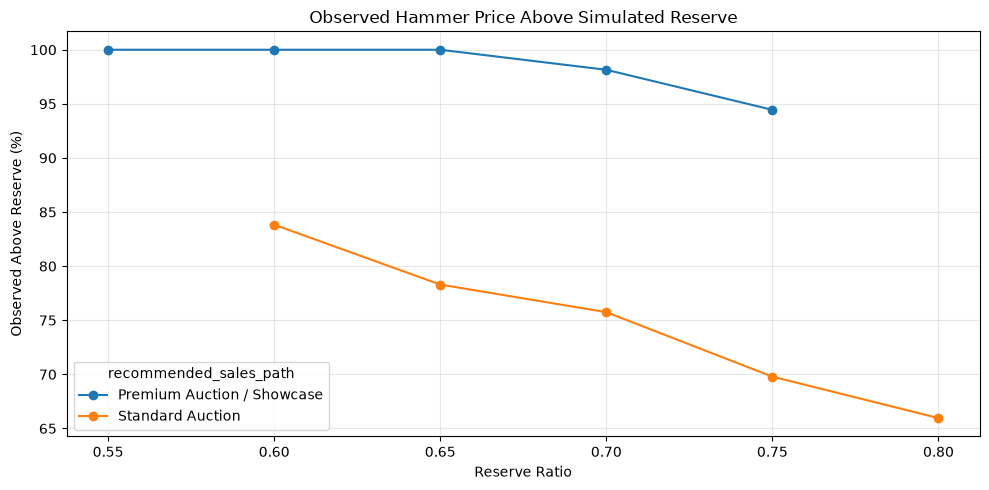

In [35]:
ax = (
    reserve_sensitivity_summary
    .pivot(
        index="reserve_ratio",
        columns="recommended_sales_path",
        values="observed_above_reserve_rate_pct",
    )
    .plot(
        marker="o",
        figsize=(10, 5),
    )
)

ax.set_title(
    "Retrospective Reserve Coverage, Not Clearance Rate"
)
ax.set_xlabel("Reserve Ratio")
ax.set_ylabel("Observed Above Reserve (%)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show(block=False)
plt.close(ax.get_figure())

## 8. Fixed-Price Markup Sensitivity

Alternative fixed-price markups are compared with observed hammer prices.

This analysis does not estimate customer conversion or time-to-sale. It only describes how the simulated list prices relate to observed auction outcomes.

In [36]:
fixed_price_scenarios = []

fixed_price_data = strategy_data.loc[
    strategy_data[
        "recommended_sales_path"
    ].eq("Fixed Price")
].copy()

for listing_ratio in [
    1.00,
    1.05,
    1.10,
    1.15,
    1.20,
]:
    simulated_fixed_price = (
        fixed_price_data[
            "valuation_central_gbp"
        ]
        * listing_ratio
    )

    observed_at_or_above_listing = (
        fixed_price_data[
            "hammer_price_gbp"
        ]
        >= simulated_fixed_price
    )

    fixed_price_scenarios.append(
        {
            "listing_price_ratio": listing_ratio,
            "plate_count": len(fixed_price_data),
            "median_simulated_fixed_price_gbp": (
                simulated_fixed_price.median()
            ),
            "median_observed_price_gbp": (
                fixed_price_data[
                    "hammer_price_gbp"
                ].median()
            ),
            "median_observed_minus_listing_gbp": (
                (
                    fixed_price_data[
                        "hammer_price_gbp"
                    ]
                    - simulated_fixed_price
                )
                .median()
            ),
            "observed_at_or_above_listing_rate_pct": (
                observed_at_or_above_listing.mean()
                * 100
            ),
        }
    )

fixed_price_sensitivity_summary = pd.DataFrame(
    fixed_price_scenarios
)

fixed_price_sensitivity_summary

,listing_price_ratio,plate_count,median_simulated_fixed_price_gbp,median_observed_price_gbp,median_observed_minus_listing_gbp,observed_at_or_above_listing_rate_pct
0,1.00,1482,"1,090.00","1,010.00",-80.00,45.48
1,1.05,1482,"1,144.50","1,010.00",-134.25,42.38
2,1.10,1482,"1,199.00","1,010.00",-187.00,40.15
3,1.15,1482,"1,253.50","1,010.00",-235.00,38.46
4,1.20,1482,"1,308.00","1,010.00",-289.00,37.18


In [37]:
review_workload_summary = (
    strategy_data.loc[
        strategy_data[
            "recommended_sales_path"
        ].eq("Specialist Review")
    ]
    .groupby(
        [
            "specialist_review_reason",
            "premium_collectibility_group",
        ]
    )
    .agg(
        plate_count=("plate_raw", "size"),
        median_observed_price_gbp=(
            "hammer_price_gbp",
            "median",
        ),
        median_predicted_price_gbp=(
            "predicted_price_gbp",
            "median",
        ),
        median_collectibility_score=(
            "collectibility_score",
            "median",
        ),
    )
    .reset_index()
    .sort_values(
        "plate_count",
        ascending=False,
    )
)

review_workload_summary

,specialist_review_reason,premium_collectibility_group,plate_count,median_observed_price_gbp,median_predicted_price_gbp,median_collectibility_score
0,high_market_value_not_fully_explained,Premium Value Only,128,"7,270.00","2,880.82",25.00
1,structural_collectibility_above_observed_value,Collectible Potential,33,"4,510.00","5,432.52",57.00
2,very_high_structural_collectibility,Premium + Collectible,31,"10,110.00","6,249.53",62.00
3,very_high_structural_collectibility|structural_collectibility_above_observed_value,Collectible Potential,18,"4,860.00","5,604.39",62.00


In [38]:
executive_strategy_summary = pd.DataFrame(
    {
        "metric": [
            "B278 portfolio rows",
            "Fixed-price recommendations",
            "Standard-auction recommendations",
            "Premium-showcase recommendations",
            "Specialist-review recommendations",
            "Specialist-review share",
            "Collectible-value review flags",
            "Material valuation-gap review flags",
            "Premium-auction reserve coverage",
            "Standard-auction reserve coverage",
        ],
        "value": [
            len(strategy_data),
            int(
                strategy_data[
                    "recommended_sales_path"
                ].eq("Fixed Price").sum()
            ),
            int(
                strategy_data[
                    "recommended_sales_path"
                ].eq("Standard Auction").sum()
            ),
            int(
                strategy_data[
                    "recommended_sales_path"
                ].eq(
                    "Premium Auction / Showcase"
                ).sum()
            ),
            int(
                strategy_data[
                    "recommended_sales_path"
                ].eq("Specialist Review").sum()
            ),
            (
                strategy_data[
                    "recommended_sales_path"
                ].eq("Specialist Review").mean()
                * 100
            ),
            int(
                strategy_data[
                    "commercial_opportunity_flag"
                ].eq("collectible_value_review").sum()
            ),
            int(
                strategy_data[
                    "commercial_opportunity_flag"
                ].eq(
                    "material_valuation_gap_review"
                ).sum()
            ),
            reserve_coverage_summary.loc[
                reserve_coverage_summary[
                    "recommended_sales_path"
                ].eq(
                    "Premium Auction / Showcase"
                ),
                "observed_price_above_reserve_rate_pct",
            ].iloc[0],
            reserve_coverage_summary.loc[
                reserve_coverage_summary[
                    "recommended_sales_path"
                ].eq("Standard Auction"),
                "observed_price_above_reserve_rate_pct",
            ].iloc[0],
        ],
        "value_type": [
            "count",
            "count",
            "count",
            "count",
            "count",
            "percent",
            "count",
            "count",
            "percent",
            "percent",
        ],
    }
)

def format_executive_value(row) -> str:
    if row["value_type"] == "count":
        return f"{int(row['value']):,}"

    if row["value_type"] == "percent":
        return f"{row['value']:.2f}%"

    if row["value_type"] == "gbp":
        return f"£{row['value']:,.0f}"

    return str(row["value"])

executive_strategy_summary["display_value"] = (
    executive_strategy_summary.apply(
        format_executive_value,
        axis=1,
    )
)

executive_strategy_summary


,metric,value
0,B278 portfolio rows,"1,981.00"
1,Fixed-price recommendations,"1,482.00"
2,Standard-auction recommendations,235.00
3,Premium-showcase recommendations,54.00
4,Specialist-review recommendations,210.00
5,Specialist-review share,10.60
6,Collectible-value review flags,46.00
7,Material valuation-gap review flags,562.00
8,Premium-auction reserve coverage,100.00
9,Standard-auction reserve coverage,75.74


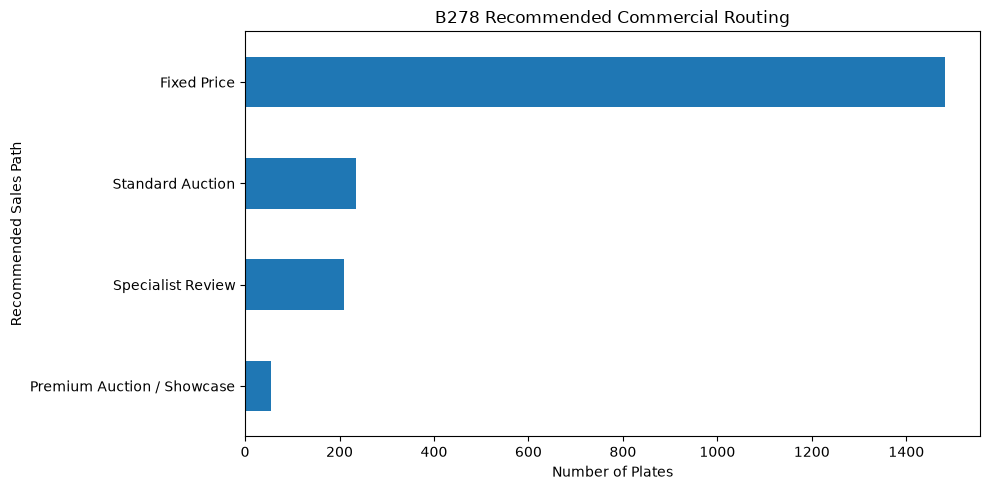

In [39]:
routing_plot_data = (
    sales_path_summary
    .set_index(
        "recommended_sales_path"
    )["plate_count"]
    .sort_values()
)

ax = routing_plot_data.plot(
    kind="barh",
    figsize=(10, 5),
)

ax.set_title(
    "B278 Recommended Commercial Routing"
)
ax.set_xlabel("Number of Plates")
ax.set_ylabel("Recommended Sales Path")

plt.tight_layout()
plt.show(block=False)
plt.close(ax.get_figure())

In [40]:
expected_sales_path_counts = {
    "Fixed Price": 1_482,
    "Standard Auction": 235,
    "Premium Auction / Showcase": 54,
    "Specialist Review": 210,
}

actual_sales_path_counts = (
    strategy_data["recommended_sales_path"]
    .value_counts()
    .to_dict()
)

assert actual_sales_path_counts == expected_sales_path_counts, (
    "Sales-path distribution changed: "
    f"{actual_sales_path_counts}"
)

expected_opportunity_counts = {
    "standard_monitoring": 1_209,
    "material_valuation_gap_review": 562,
    "specialist_assessment": 164,
    "collectible_value_review": 46,
}

actual_opportunity_counts = (
    strategy_data["commercial_opportunity_flag"]
    .value_counts()
    .to_dict()
)

assert actual_opportunity_counts == expected_opportunity_counts, (
    "Commercial-opportunity distribution changed: "
    f"{actual_opportunity_counts}"
)

assert len(df_valuation) == 1_981
assert len(df_assets_test) == 1_981
assert len(strategy_data) == 1_981
assert len(pricing_strategy_decisions) == 1_981

business_key = ["event_code", "lot_number"]

assert not df_valuation.duplicated(business_key).any()
assert not df_assets_test.duplicated(business_key).any()
assert not strategy_data.duplicated(business_key).any()
assert not pricing_strategy_decisions.duplicated(business_key).any()

assert strategy_data["collectibility_score"].notna().all()
assert strategy_data["recommended_sales_path"].notna().all()
assert actual_sales_path_counts.values()
assert sum(actual_sales_path_counts.values()) == 1_981
assert sum(actual_opportunity_counts.values()) == 1_981

assert (
    actual_opportunity_counts["specialist_assessment"]
    + actual_opportunity_counts["collectible_value_review"]
    == expected_sales_path_counts["Specialist Review"]
)

price_columns = [
    "hammer_price_gbp",
    "predicted_price_gbp",
    "valuation_low_gbp",
    "valuation_central_gbp",
    "valuation_high_gbp",
]

assert (strategy_data[price_columns] >= 0).all().all()

for price_column in [
    "recommended_fixed_price_gbp",
    "recommended_reserve_price_gbp",
]:
    assert (
        strategy_data[price_column]
        .dropna()
        .ge(0)
        .all()
    )

assert strategy_data.loc[
    specialist_mask,
    "recommended_fixed_price_gbp",
].isna().all()

assert strategy_data.loc[
    specialist_mask,
    "recommended_reserve_price_gbp",
].isna().all()

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

report_outputs = {
    "pricing_policy_assumptions_2025.csv": pricing_policy,
    "predicted_value_tier_summary_2025.csv": predicted_value_tier_summary,
    "sales_path_summary_2025.csv": sales_path_summary,
    "reserve_coverage_summary_2025.csv": reserve_coverage_summary,
    "fixed_price_retrospective_summary_2025.csv": fixed_price_summary,
    "strategy_calibration_summary_2025.csv": strategy_calibration_summary,
    "commercial_opportunity_summary_2025.csv": commercial_opportunity_summary,
    "reserve_policy_sensitivity_2025.csv": reserve_sensitivity_summary,
    "fixed_price_markup_sensitivity_2025.csv": fixed_price_sensitivity_summary,
    "specialist_review_workload_2025.csv": review_workload_summary,
    "executive_pricing_strategy_summary_2025.csv": executive_strategy_summary,
    "pricing_and_auction_strategy_decisions_2025.csv": pricing_strategy_decisions,
}

for report_name, report_data in report_outputs.items():
    report_data.to_csv(
        REPORTS_DIR / report_name,
        index=False,
    )

export_manifest = pd.DataFrame(
    [
        {
            "report_name": report_name,
            "path": str(REPORTS_DIR / report_name),
            "exists": (REPORTS_DIR / report_name).exists(),
            "row_count": len(
                pd.read_csv(REPORTS_DIR / report_name)
            ),
        }
        for report_name in report_outputs
    ]
)

assert export_manifest["exists"].all()
assert (
    export_manifest.loc[
        export_manifest["report_name"].eq(
            "pricing_and_auction_strategy_decisions_2025.csv"
        ),
        "row_count",
    ].iloc[0]
    == 1_981
)

print("Final technical checks passed.")
print(
    "Pricing and auction-strategy reports "
    "saved successfully."
)

export_manifest


Pricing and auction-strategy reports saved successfully.


## 9. Pricing and Auction Strategy Conclusion

This notebook converted valuation and collectibility outputs into an explainable **pricing and auction strategy simulation** for the untouched B278 event. It is a decision-support framework, not a completed dynamic pricing optimisation system.

### Portfolio routing

- 1,482 registrations were directed to the indicative fixed-price pathway.
- 235 registrations were directed to standard auction.
- 54 registrations were identified for premium auction or showcase treatment.
- 210 registrations were withheld from automatic pricing and routed for specialist review.

The routing groups are commercially distinct. Median observed hammer prices were approximately £1,010 for Fixed Price, £3,260 for Standard Auction, £6,730 for Specialist Review, and £7,005 for Premium Auction / Showcase.

### Pricing-policy simulation

- Fixed Price used a transparent 1.10x listing assumption over the central valuation.
- Standard Auction used a 0.70x simulated reserve assumption.
- Premium Auction / Showcase used a 0.65x simulated reserve assumption.
- Specialist Review received no automatic fixed-price or reserve recommendation.

Observed B278 hammer prices exceeded the simulated reserve for approximately 75.74% of Standard Auction assets and 100% of Premium Auction / Showcase assets. This is **retrospective reserve coverage**. It does not estimate sell-through, bidder response, or causal revenue impact.

### Commercial investigation signals

The decision layer produces commercial investigation flags rather than missed-revenue claims. The specialist-review group is split into 164 `specialist_assessment` cases and 46 `collectible_value_review` cases, so all 210 high-touch assets are assigned to exactly one more specific review path.

### Governance and limitations

The public dataset does not include bidder history, bid sequence, listing duration, customer-level demand, conversion, price elasticity, reserve experiments, or true unsold / withdrawn outcomes. Therefore, the results should be framed as scenario analysis rather than proof of optimised revenue, causal auction-format effects, definitive missed value, or mathematically optimal reserve levels.

The correct interpretation is an indicative pricing policy, retrospective reserve coverage analysis, commercial investigation flagging layer, and decision-support framework that can later be calibrated with internal marketplace data and controlled experiments.
